# CNN from Scratch on MNIST
### Building, Training & Evaluating a Convolutional Neural Network

This notebook walks through building a **CNN** on the famous **MNIST** dataset (60 000 training / 10 000 test grayscale images of handwritten digits 0–9, each **28 × 28 pixels**).

**What you will learn:**
- How each CNN layer (convolution, pooling, dropout, activation) works and **why** it is placed where it is
- How to choose good hyperparameters from the start
- How to track training progress and spot over/underfitting from a graph
- Practical advice for pushing accuracy higher

> **Target accuracy:** ≥ 99 % on the test set — achievable with this architecture in ~10 epochs.

In [14]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import random

In [15]:
# Run this once to load the train and test data straight into a dataloader class
# that will provide the batches
batch_size_train = 64
batch_size_test = 1000
train_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('/files/', train=True, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
  batch_size=batch_size_train, shuffle=True)

test_loader = torch.utils.data.DataLoader(
  torchvision.datasets.MNIST('/files/', train=False, download=True,
                             transform=torchvision.transforms.Compose([
                               torchvision.transforms.ToTensor(),
                               torchvision.transforms.Normalize(
                                 (0.1307,), (0.3081,))
                             ])),
  batch_size=batch_size_test, shuffle=True)

## Step 1 — Load & Pre-process the Data

### Why do we normalise?

Raw pixel values are integers in **[0, 255]** (or floats in [0, 1] after `ToTensor()`).
Feeding large, uncentered values into a network leads to:
- very large activations early in training → exploding / unstable gradients
- slow convergence because each feature dimension lives on a very different scale

**Normalisation formula applied per pixel:**
$$\hat{x} = \frac{x - \mu}{\sigma}$$

For MNIST the dataset-wide statistics are:
| Statistic | Value |
|-----------|-------|
| Mean (μ)  | 0.1307 |
| Std  (σ)  | 0.3081 |

These numbers were computed over the full 60 000 training images once and are standard practice for MNIST.
After normalisation pixels sit roughly in **[-1, 1]** → network learns much faster.

### Why shuffle the training loader but not the test loader?
- **Training shuffle = ON** → the model sees a different order every epoch, preventing it from "memorising the order" of batches (reduces overfitting).
- **Test shuffle = OFF** → we want reproducible, deterministic evaluation.

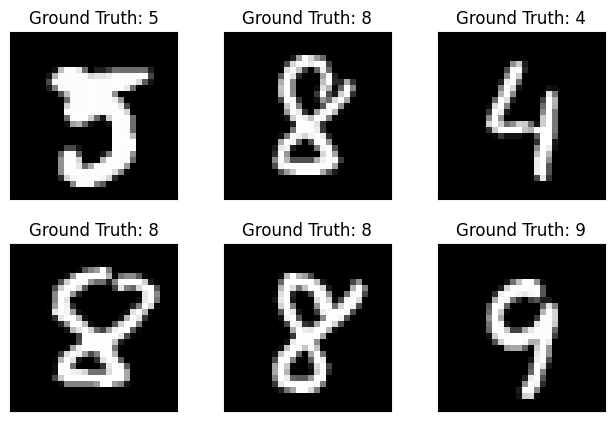

In [16]:
# Let's draw some of the training data
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

fig = plt.figure()
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Ground Truth: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])
plt.show()

## Step 2 — Define the CNN Architecture

We will build a **LeNet-inspired CNN** following the classic pattern:

```
Input (1×28×28)
   │
   ├─ Conv Block 1: Conv(1→10, k=5) → MaxPool(2) → ReLU
   │     output: 10×12×12
   │
   ├─ Conv Block 2: Conv(10→20, k=5) → Dropout2d → MaxPool(2) → ReLU
   │     output: 20×4×4
   │
   └─ Classifier: Flatten → FC(320→50) → ReLU → Dropout → FC(50→10) → LogSoftmax
```

### Why these design choices?

| Component | Reason |
|-----------|--------|
| **kernel_size=5, no padding ("valid")** | Each conv slides a 5×5 filter over the image and extracts local features (edges, curves). No padding means we shrink the spatial size slightly — that's fine here. |
| **MaxPool(2×2)** | Halves width and height, keeping only the strongest activation in each 2×2 area. Makes the model translation-invariant and reduces computation. |
| **ReLU** | Non-linear activation that is fast to compute and avoids the vanishing-gradient problem of sigmoid/tanh. Gold standard for CNNs. |
| **Dropout2d(p=0.25)** | Randomly zeros *entire feature maps* during training → stronger regularisation than scalar dropout for convolutional layers. |
| **Dropout(p=0.5) in FC** | The fully-connected layers have many parameters and are prone to overfitting. 50% dropout is a proven default (from AlexNet). |
| **log_softmax + NLLLoss** | Equivalent to CrossEntropyLoss but numerically more stable. PyTorch's `CrossEntropyLoss` does the same thing internally. |

> **Spatial size math** (always useful to verify manually):
> - After Conv(k=5, no padding): size = input − 4
> - After MaxPool(2): size = input / 2
>
> So: 28 →(conv1)→ 24 →(pool)→ 12 →(conv2)→ 8 →(pool)→ 4
> Flatten: **20 × 4 × 4 = 320** features enter the first FC layer.

In [17]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()

        # ── Convolutional Block 1 ───────────────────────────────────────────
        # "valid" conv (no padding): 1×28×28  →  10×24×24
        # kernel_size=5 captures 5×5 local patterns (edges, curves)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=10, kernel_size=5)
        # MaxPool halves spatial dims: 10×24×24  →  10×12×12
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # ── Convolutional Block 2 ───────────────────────────────────────────
        # "valid" conv: 10×12×12  →  20×8×8
        # doubling the channels (10→20) lets the network learn richer features
        self.conv2 = nn.Conv2d(in_channels=10, out_channels=20, kernel_size=5)
        # Dropout2d zeros ENTIRE feature maps (p=0.25 → 25% of maps dropped)
        # stronger regularisation than scalar dropout for conv layers
        self.drop2d = nn.Dropout2d(p=0.25)
        # MaxPool: 20×8×8  →  20×4×4
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # ── Fully-Connected Classifier ──────────────────────────────────────
        # After flatten: 20 × 4 × 4 = 320  →  compute it with: 28→24→12→8→4
        self.fc1 = nn.Linear(320, 50)
        # Dropout(0.5) before the last layer is the AlexNet standard
        # it forces the network not to rely on any single neuron
        self.drop_fc = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(50, 10)   # 10 output logits (one per digit class)

    def forward(self, x):
        # Block 1: conv → pool → relu
        x = F.relu(self.pool1(self.conv1(x)))

        # Block 2: conv → spatial-dropout → pool → relu
        x = F.relu(self.pool2(self.drop2d(self.conv2(x))))

        # Flatten: [batch, 20, 4, 4]  →  [batch, 320]
        x = x.view(-1, 320)

        # Classifier
        x = F.relu(self.fc1(x))
        x = self.drop_fc(x)
        x = self.fc2(x)

        # log_softmax + F.nll_loss is numerically equivalent to CrossEntropyLoss
        # but more explicit about what is happening
        return F.log_softmax(x, dim=1)

In [18]:
# He initialization of weights
def weights_init(layer_in):
  if isinstance(layer_in, nn.Linear):
    nn.init.kaiming_uniform_(layer_in.weight)
    layer_in.bias.data.fill_(0.0)

## Step 3 — Initialisation & Optimiser

### Weight Initialisation — He (Kaiming) Uniform
The function below initialises every `Linear` layer using **He initialisation**:

$$W \sim \mathcal{U}\!\left(-\sqrt{\frac{6}{fan\_in}},\; +\sqrt{\frac{6}{fan\_in}}\right)$$

**Why?** ReLU cuts negative values to zero, so roughly half the neurons are inactive at initialisation. He initialisation compensates for this by scaling weights larger than Xavier/Glorot — it keeps the variance of activations constant across layers so gradients neither explode nor vanish.

> PyTorch's `nn.Conv2d` already uses Kaiming by default, so we apply the custom init only to `nn.Linear` layers.

---

### Optimiser — Adam (lr = 0.001, weight_decay = 1e-4)

| Hyperparameter | Value | Why |
|---------------|-------|-----|
| **Optimiser** | Adam | Combines momentum + per-parameter adaptive learning rates. Converges faster than plain SGD for most tasks. Great default for beginners. |
| **Learning rate** | 0.001 | The universally recommended Adam starting point. Too high → loss explodes. Too low → painfully slow. |
| **Weight decay** | 1e-4 | L2 regularisation: adds a tiny penalty for large weights → reduces overfitting without hurting accuracy much. |
| **Batch size** | 64 | Small enough to have noisy gradients (which act as regularisation), large enough for GPU efficiency. |

In [19]:
import os
# Helps surface CUDA errors immediately instead of deferring them
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

model = Net().to(device)

# Apply He initialisation to all Linear layers
model.apply(weights_init)

# Adam: momentum + adaptive lr per parameter — best default for beginners
# weight_decay=1e-4 is L2 regularisation (prevents overfitting)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Print a summary of the model architecture and parameter count
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Using device: cuda
  GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
  VRAM: 6.4 GB
Net(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(10, 20, kernel_size=(5, 5), stride=(1, 1))
  (drop2d): Dropout2d(p=0.25, inplace=False)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=320, out_features=50, bias=True)
  (drop_fc): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
)

Total parameters:     21,840
Trainable parameters: 21,840


In [20]:
def train(epoch):
    """Train for one epoch and return (avg_loss, accuracy)."""
    model.train()   # activates Dropout and BatchNorm (if any)

    total_loss = 0.0
    correct = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)  # send to GPU/CPU

        optimizer.zero_grad()          # clear gradients from previous step
        output = model(data)           # forward pass
        loss = F.nll_loss(output, target)  # negative log-likelihood loss
        loss.backward()                # compute gradients via backprop
        optimizer.step()               # update weights

        total_loss += loss.item() * len(data)
        pred = output.data.max(1, keepdim=True)[1]
        correct += pred.eq(target.data.view_as(pred)).sum().item()

        # Print progress every 200 batches
        if batch_idx % 200 == 0:
            print(f"  [{batch_idx * len(data):>5}/{len(train_loader.dataset)}]  "
                  f"loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader.dataset)
    accuracy = 100.0 * correct / len(train_loader.dataset)
    return avg_loss, accuracy

In [21]:
def test():
    """Evaluate on the test set and return (avg_loss, accuracy)."""
    model.eval()   # disables Dropout — we want deterministic predictions

    test_loss = 0.0
    correct = 0

    with torch.no_grad():   # no gradient tracking needed during evaluation
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            # reduction='sum' accumulates loss over all samples, we divide later
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.data.max(1, keepdim=True)[1]
            correct += pred.eq(target.data.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100.0 * correct / len(test_loader.dataset)
    return test_loss, accuracy

In [22]:
## Step 4 — Train the Network

n_epochs = 15   # 10 epochs is plenty for MNIST with Adam; increase to 15 if you want more

# Lists to record metrics each epoch for plotting
train_losses, train_accs = [], []
test_losses,  test_accs  = [], []

# Evaluate BEFORE any training (epoch 0 baseline)
te_loss, te_acc = test()
print(f"Epoch 0 (untrained) → Test loss: {te_loss:.4f}, Test acc: {te_acc:.1f}%\n")
test_losses.append(te_loss)
test_accs.append(te_acc)

for epoch in range(1, n_epochs + 1):
    print(f"── Epoch {epoch}/{n_epochs} ──────────────────────")
    tr_loss, tr_acc = train(epoch)
    te_loss, te_acc = test()

    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    test_losses.append(te_loss)
    test_accs.append(te_acc)

    print(f"  Train → loss: {tr_loss:.4f}, acc: {tr_acc:.1f}%")
    print(f"  Test  → loss: {te_loss:.4f}, acc: {te_acc:.1f}%\n")

print(f"Best Test Accuracy: {max(test_accs):.2f}%  (epoch {test_accs.index(max(test_accs))})")

Epoch 0 (untrained) → Test loss: 2.3980, Test acc: 8.3%

── Epoch 1/15 ──────────────────────
  [    0/60000]  loss: 2.5637
  [12800/60000]  loss: 0.4418
  [25600/60000]  loss: 0.4307
  [38400/60000]  loss: 0.4153
  [51200/60000]  loss: 0.2125
  Train → loss: 0.5036, acc: 84.0%
  Test  → loss: 0.0844, acc: 97.3%

── Epoch 2/15 ──────────────────────
  [    0/60000]  loss: 0.3544
  [12800/60000]  loss: 0.2253
  [25600/60000]  loss: 0.1217
  [38400/60000]  loss: 0.1246
  [51200/60000]  loss: 0.1010
  Train → loss: 0.1947, acc: 94.4%
  Test  → loss: 0.0571, acc: 98.2%

── Epoch 3/15 ──────────────────────
  [    0/60000]  loss: 0.0986
  [12800/60000]  loss: 0.1440
  [25600/60000]  loss: 0.0324
  [38400/60000]  loss: 0.1947
  [51200/60000]  loss: 0.0732
  Train → loss: 0.1594, acc: 95.4%
  Test  → loss: 0.0465, acc: 98.5%

── Epoch 4/15 ──────────────────────
  [    0/60000]  loss: 0.1418
  [12800/60000]  loss: 0.1436
  [25600/60000]  loss: 0.1317
  [38400/60000]  loss: 0.0785
  [51200/600

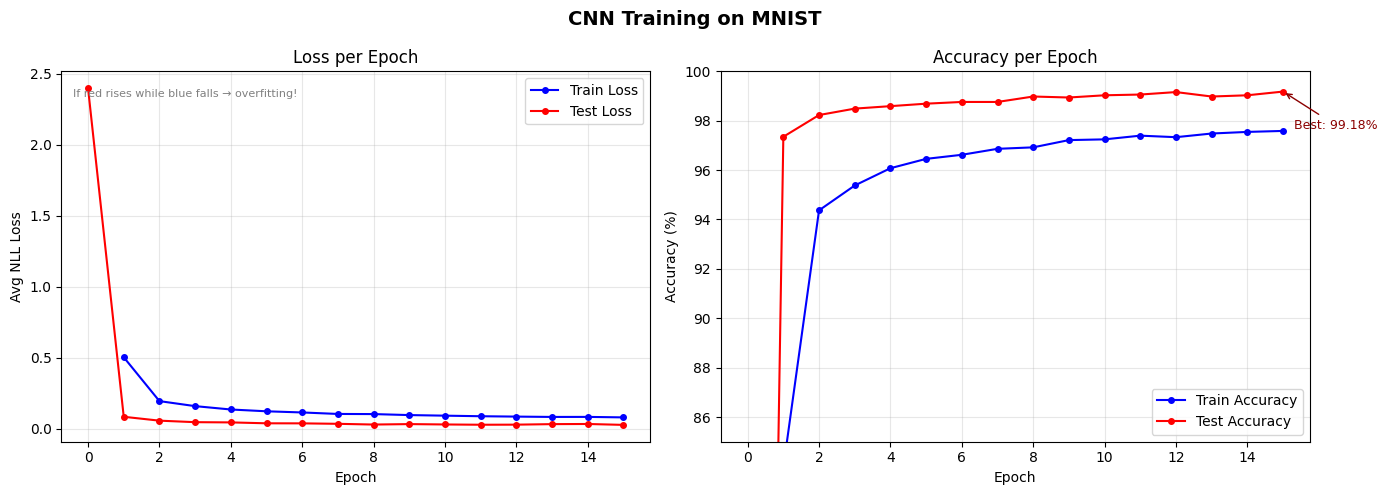

Final Test Accuracy : 99.18%
Best  Test Accuracy : 99.18%  at epoch 15


In [23]:
## Step 5 — Visualise Training Progress

epochs_range = range(len(test_losses))          # 0 … n_epochs  (includes baseline)
train_epochs = range(1, len(train_losses) + 1)  # 1 … n_epochs

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("CNN Training on MNIST", fontsize=14, fontweight="bold")

# ── Loss curve ──────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(train_epochs, train_losses, "b-o", markersize=4, label="Train Loss")
ax.plot(epochs_range, test_losses,  "r-o", markersize=4, label="Test Loss")
ax.set_title("Loss per Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Avg NLL Loss")
ax.legend()
ax.grid(True, alpha=0.3)
# Overfitting signal: if the red curve rises while the blue keeps falling → overfit
ax.annotate("If red rises while blue falls → overfitting!", xy=(0.02, 0.93),
            xycoords="axes fraction", fontsize=8, color="grey")

# ── Accuracy curve ──────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(train_epochs, train_accs, "b-o", markersize=4, label="Train Accuracy")
ax.plot(epochs_range, test_accs,  "r-o", markersize=4, label="Test Accuracy")
ax.set_title("Accuracy per Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([85, 100])   # MNIST typically 97–99 %

# Mark the best test epoch
best_epoch = int(np.argmax(test_accs))
ax.annotate(f"Best: {max(test_accs):.2f}%",
            xy=(best_epoch, max(test_accs)),
            xytext=(best_epoch + 0.3, max(test_accs) - 1.5),
            arrowprops=dict(arrowstyle="->", color="darkred"),
            color="darkred", fontsize=9)

plt.tight_layout()
plt.show()

print(f"Final Test Accuracy : {test_accs[-1]:.2f}%")
print(f"Best  Test Accuracy : {max(test_accs):.2f}%  at epoch {best_epoch}")

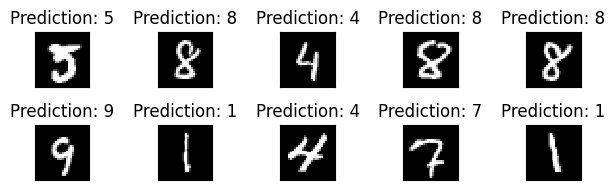

In [24]:
# Run network on data we got before and show predictions
output = model(example_data.to(device))

fig = plt.figure()
for i in range(10):
  plt.subplot(5, 5, i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
  plt.title("Prediction: {}".format(
    output.data.max(1, keepdim=True)[1][i].item()))
  plt.xticks([])
  plt.yticks([])
plt.show()

## Hyperparameter Tuning Guide

After training, use the curves to diagnose what to change next.

### Diagnose your curves first

| What you see | Diagnosis | Fix |
|---|---|---|
| Train acc high, Test acc much lower | **Overfitting** | More dropout, add weight decay, fewer channels, data augmentation |
| Both accs low and flat | **Underfitting** | Bigger network (more channels/blocks), lower lr, more epochs |
| Loss oscillates wildly | **Learning rate too high** | Try `lr = 0.0001` |
| Loss decreases very slowly | **Learning rate too low** | Try `lr = 0.005` or `lr = 0.01` |
| Test loss rises after epoch N | **Overfitting starts at epoch N** | Use **early stopping**: save the checkpoint at the best validation epoch |

---

### Priority order for tuning

```
1. Learning Rate  →  most impactful parameter
   try: 0.01 → 0.001 (current) → 0.0001

2. Batch Size
   32  → smoother loss but slower per epoch
   128 → faster epochs but noisier loss

3. Dropout
   conv blocks: 0.1 – 0.3   (0.25 is a good start)
   FC layers:   0.4 – 0.5   (0.5 is AlexNet standard)

4. Network depth / width
   → add a 3rd conv block (64→128 channels) if underfitting
   → increase FC hidden size from 50 → 128 or 256

5. Epochs
   → 10 is usually enough for MNIST; bump to 15–20 if still improving

6. Optimiser switch (advanced)
   → Replace Adam with SGD + momentum=0.9 + lr=0.01 + StepLR scheduler
     (often reaches slightly higher final accuracy with more tuning)
```

### Quick tricks to squeeze out the last 0.5 %

- **Learning rate scheduler**: decay lr every 5 epochs
  ```python
  scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
  # call scheduler.step() after each epoch
  ```
- **Data augmentation** (minimal for MNIST, but helps):
  ```python
  torchvision.transforms.RandomAffine(degrees=10, translate=(0.1, 0.1))
  ```
- **Test-time augmentation**: average predictions over slight crops/flips.
- **BatchNorm** after each conv: stabilises training and often allows a higher lr.

> **Remember:** never tune hyperparameters by looking at the test set!
> Create a proper **validation split** (e.g., 10 % of training data) and keep
> the test set locked until the very end.